# Image Type Analysis (S vs V)

Best pipeline: sharpen_clahe_resize
Baseline pipeline: baseline_resize
Num classes: 5
image_type
S    1521
V      47
Name: count, dtype: int64


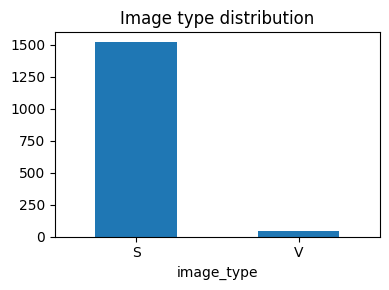

image_type,S,V
Label,,
Benign Stricture,63,0
Biliary Leaks,146,5
Lithiasis,712,14
Malignant Stricture,324,5
Normal,276,23


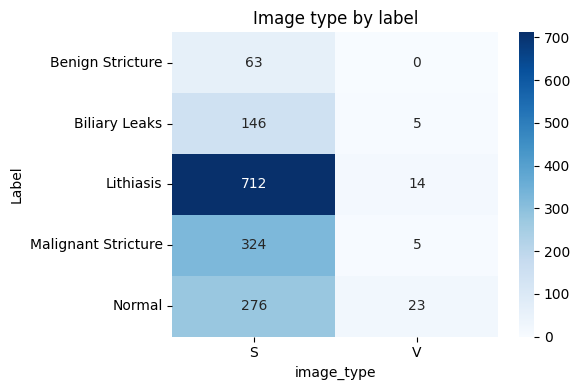

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image

DATA_ROOT = '/mounts/mecd-ap-g5/data'
RESULTS_DIR = '/mounts/mecd-ap-g5/results/filter_benchmark_clahe'
MODELS_DIR = '/mounts/mecd-ap-g5/models/filter_benchmark_clahe'

summary_path = os.path.join(RESULTS_DIR, 'pipeline_benchmark_summary.csv')
assert os.path.exists(summary_path), f'No pipeline summary found at {summary_path}'
df = pd.read_csv(summary_path)
df_sorted = df.sort_values(by='test_macro_f1', ascending=False).reset_index(drop=True)
best_pipeline = df_sorted.loc[0, 'pipeline_name']
baseline_pipeline = 'baseline_resize'
print(f'Best pipeline: {best_pipeline}')
print(f'Baseline pipeline: {baseline_pipeline}')

meta = pd.read_csv(os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv'))
EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
filtered = meta[(meta['Keep'].astype(str).str.strip().str.lower() == 'keep') & (~meta['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))].copy()
if 'image_type' not in filtered.columns:
    raise ValueError('metadata.csv missing image_type column')
filtered['image_path'] = filtered['processed_image_path'].apply(lambda p: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', p))
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy()
label_cat = pd.Categorical(filtered['Label'])
filtered['label_idx'] = label_cat.codes
class_names = list(label_cat.categories)
num_classes = len(class_names)
print('Num classes:', num_classes)

# Image type distribution
type_counts = filtered['image_type'].value_counts(dropna=False)
print(type_counts)
plt.figure(figsize=(4, 3))
type_counts.plot(kind='bar', rot=0)
plt.title('Image type distribution')
plt.tight_layout()
plt.show()

# Image type distribution by label
type_by_label = pd.crosstab(filtered['Label'], filtered['image_type'])
display(type_by_label)
plt.figure(figsize=(6, 4))
sns.heatmap(type_by_label, annot=True, fmt='d', cmap='Blues')
plt.title('Image type by label')
plt.tight_layout()
plt.show()

Best pipeline per-type:


/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,accuracy,balanced_accuracy,macro_f1,image_type,n
0,0.483333,0.364002,0.320542,S,240
1,0.916667,0.500000,0.478261,V,12


Baseline pipeline per-type:


,accuracy,balanced_accuracy,macro_f1,image_type,n
0,0.3625,0.355115,0.282609,S,240
1,0.5000,0.272727,0.222222,V,12


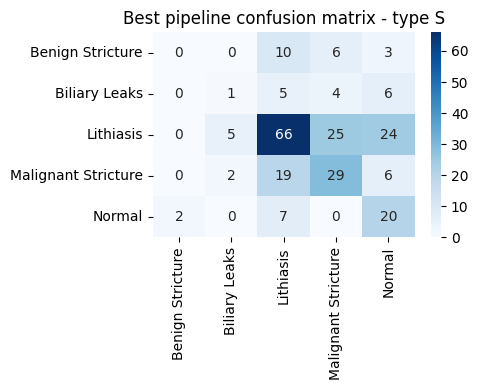

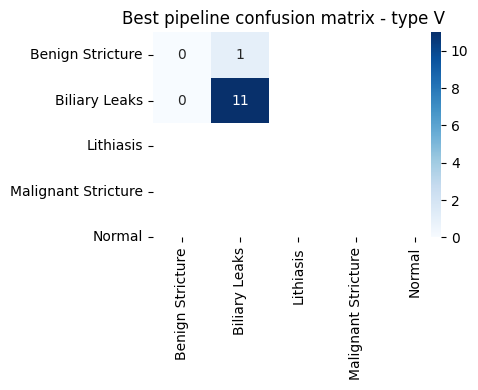

In [5]:
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from torchvision import models, transforms
from torch.utils.data import Dataset
import cv2
from PIL import ImageFilter

SEED = 42
IMG_SIZE = 320
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def build_resnet50(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def resize_square(image, size=IMG_SIZE):
    return image.resize((size, size), Image.BILINEAR)

def apply_clahe_rgb(image, clip_limit=2.0, tile_grid_size=(8, 8)):
    arr = np.array(image)
    lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    rgb = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
    return Image.fromarray(rgb)

def apply_mild_denoise(image):
    arr = np.array(image)
    den = cv2.fastNlMeansDenoisingColored(arr, None, 3, 3, 7, 21)
    return Image.fromarray(den)

def apply_unsharp_mask(image):
    return image.filter(ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3))

PIPELINES = {
    'baseline_resize': lambda img: resize_square(img),
    'clahe_resize': lambda img: resize_square(apply_clahe_rgb(img, clip_limit=2.0, tile_grid_size=(8, 8))),
    'denoise_clahe_resize': lambda img: resize_square(apply_clahe_rgb(apply_mild_denoise(img), clip_limit=2.0, tile_grid_size=(8, 8))),
    'sharpen_clahe_resize': lambda img: resize_square(apply_clahe_rgb(apply_unsharp_mask(img), clip_limit=2.0, tile_grid_size=(8, 8))),
}

patient_summary = filtered.groupby('patient_id').agg(patient_label=('Label', lambda values: values.mode().iloc[0])).reset_index()
train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label'],
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label'],
)
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy()

class PipelineDataset(Dataset):
    def __init__(self, dataframe, pipeline_name, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.pipeline_name = pipeline_name
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = PIPELINES[self.pipeline_name](img)
        if self.transform is not None:
            img = self.transform(img)
        return img, int(row['label_idx'])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def run_inference(model, pipeline_name, batch_size=64):
    test_dataset = PipelineDataset(test_df, pipeline_name=pipeline_name, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    all_t = []
    all_p = []
    device_local = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device_local)
    model.eval()
    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device_local)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_t.extend(targets.numpy().tolist())
            all_p.extend(preds.tolist())
    return np.array(all_t), np.array(all_p)

def compute_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro')),
    }

def evaluate_by_type(pipeline_name):
    model_path = os.path.join(MODELS_DIR, f'{pipeline_name}_resnet50.pth')
    if not os.path.exists(model_path):
        raise FileNotFoundError(model_path)
    model = build_resnet50(num_classes)
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    y_true, y_pred = run_inference(model, pipeline_name, batch_size=32)
    test_df_local = test_df.copy()
    test_df_local['y_true'] = y_true
    test_df_local['y_pred'] = y_pred
    results = []
    for image_type in sorted(test_df_local['image_type'].dropna().unique()):
        subset = test_df_local[test_df_local['image_type'] == image_type]
        metrics = compute_metrics(subset['y_true'].values, subset['y_pred'].values)
        metrics['image_type'] = image_type
        metrics['n'] = int(len(subset))
        results.append(metrics)
    return pd.DataFrame(results).sort_values(by='image_type'), y_true, y_pred, model

best_by_type, y_true_best, y_pred_best, model_best = evaluate_by_type(best_pipeline)
baseline_by_type, y_true_base, y_pred_base, model_base = evaluate_by_type(baseline_pipeline)
print('Best pipeline per-type:')
display(best_by_type)
print('Baseline pipeline per-type:')
display(baseline_by_type)

# Confusion matrices per type for best pipeline
test_df_best = test_df.copy()
test_df_best['y_true'] = y_true_best
test_df_best['y_pred'] = y_pred_best
for image_type in sorted(test_df_best['image_type'].dropna().unique()):
    subset = test_df_best[test_df_best['image_type'] == image_type]
    cm = confusion_matrix(subset['y_true'], subset['y_pred'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(f'Best pipeline confusion matrix - type {image_type}')
    plt.tight_layout()
    plt.show()

No correct prediction found for label: Benign Stricture


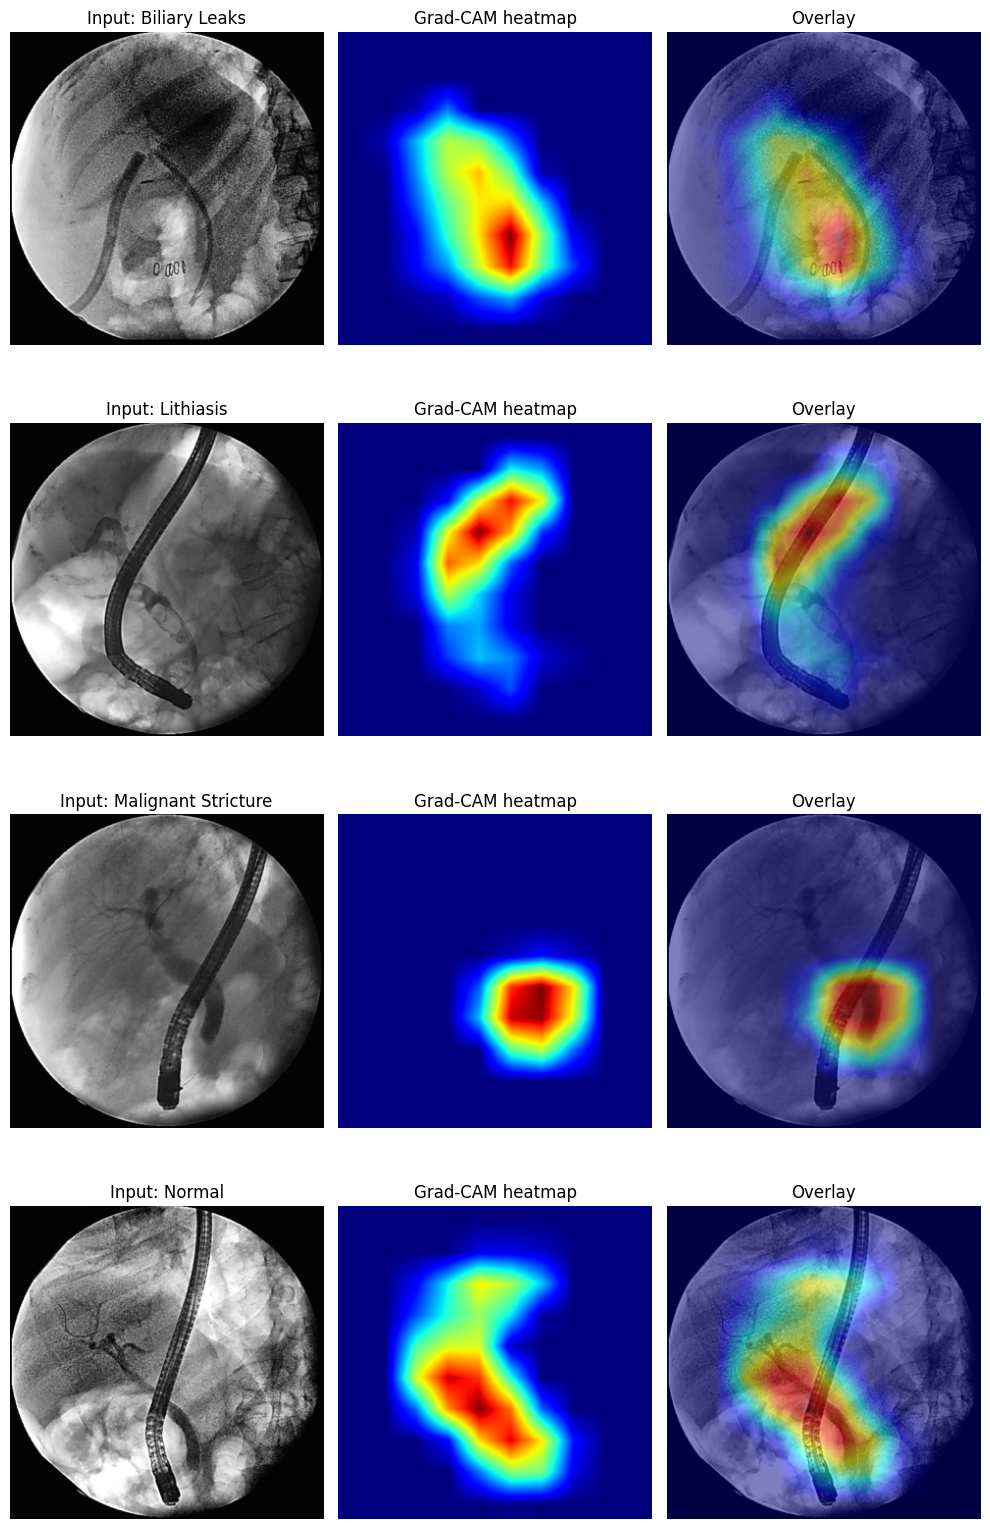

In [6]:
# Grad-CAM for interpretability (one correct example per label)
def get_target_layer(model):
    return model.layer4[-1].conv3

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(_, __, output):
            self.activations = output.detach()
        def backward_hook(_, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, target_idx):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        score = logits[:, target_idx].sum()
        score.backward(retain_graph=True)
        grads = self.gradients
        acts = self.activations
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        return cam

def overlay_cam(image_pil, cam, alpha=0.5):
    img = np.array(image_pil)
    heat = (cam * 255).astype(np.uint8)
    heat = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heat + (1 - alpha) * img).astype(np.uint8)
    return overlay

def show_gradcam_per_label(patch_dir=None):
    device_local = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_best.to(device_local)
    model_best.eval()
    gradcam = GradCAM(model_best, get_target_layer(model_best))
    picks = []
    for label_idx, label_name in enumerate(class_names):
        idxs = np.where((y_true_best == y_pred_best) & (y_true_best == label_idx))[0]
        if len(idxs) > 0:
            picks.append(int(idxs[0]))
        else:
            print(f'No correct prediction found for label: {label_name}')
    if len(picks) == 0:
        print('No correct predictions to visualize.')
        return
    if patch_dir:
        os.makedirs(patch_dir, exist_ok=True)
    fig, axes = plt.subplots(len(picks), 3, figsize=(10, 4 * len(picks)))
    if len(picks) == 1:
        axes = np.expand_dims(axes, axis=0)
    for i, idx in enumerate(picks):
        row = test_df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        proc = PIPELINES[best_pipeline](img)
        target_idx = int(y_pred_best[idx])
        input_tensor = transform(proc).unsqueeze(0).to(device_local)
        cam = gradcam(input_tensor, target_idx)
        overlay = overlay_cam(proc, cam, alpha=0.5)
        axes[i, 0].imshow(proc)
        axes[i, 0].set_title(f'Input: {class_names[target_idx]}')
        axes[i, 0].axis('off')
        axes[i, 1].imshow(cam, cmap='jet')
        axes[i, 1].set_title('Grad-CAM heatmap')
        axes[i, 1].axis('off')
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')
        if patch_dir:
            Image.fromarray(overlay).save(os.path.join(patch_dir, f'gradcam_{class_names[target_idx]}_{idx}.png'))
    plt.tight_layout()
    plt.show()

# Run Grad-CAM examples
out_dir = os.path.join(RESULTS_DIR, 'type_analysis', 'gradcam')
show_gradcam_per_label(patch_dir=out_dir)

In [8]:
# XGBoost baseline on deep features (ResNet50 penultimate layer)
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    use_xgb = True
except Exception as e:
    print('xgboost not available, falling back to LogisticRegression:', e)
    use_xgb = False
    from sklearn.linear_model import LogisticRegression

class FeatureDataset(Dataset):
    def __init__(self, dataframe, pipeline_name, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.pipeline_name = pipeline_name
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = PIPELINES[self.pipeline_name](img)
        if self.transform is not None:
            img = self.transform(img)
        return img, int(row['label_idx']), str(row['image_type'])

def extract_features(df_in, pipeline_name, batch_size=32):
    dataset = FeatureDataset(df_in, pipeline_name=pipeline_name, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    device_local = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    backbone = nn.Sequential(*list(backbone.children())[:-1]).to(device_local)
    backbone.eval()
    feats, labels, types = [], [], []
    with torch.no_grad():
        for images, y, t in loader:
            images = images.to(device_local)
            f = backbone(images).squeeze(-1).squeeze(-1).cpu().numpy()
            feats.append(f)
            labels.extend(y.numpy().tolist())
            types.extend(list(t))
    return np.vstack(feats), np.array(labels), np.array(types)

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy()
val_df = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy()
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy()

X_train, y_train, t_train = extract_features(train_df, best_pipeline, batch_size=32)
X_val, y_val, t_val = extract_features(val_df, best_pipeline, batch_size=32)
X_test, y_test, t_test = extract_features(test_df, best_pipeline, batch_size=32)

if use_xgb:
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist',
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
else:
    model = make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(max_iter=2000, multi_class='multinomial', n_jobs=-1),
    )
    model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('XGBoost/Linear baseline overall:')
print(compute_metrics(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_names))

# Per-type metrics
for image_type in sorted(np.unique(t_test)):
    mask = t_test == image_type
    print(f'Per-type metrics for {image_type} (n={mask.sum()}):')
    print(compute_metrics(y_test[mask], y_pred[mask]))

XGBoost/Linear baseline overall:
{'accuracy': 0.46825396825396826, 'balanced_accuracy': 0.22471664698937427, 'macro_f1': 0.19804855911050603}
                     precision    recall  f1-score   support

   Benign Stricture       0.00      0.00      0.00        19
      Biliary Leaks       0.00      0.00      0.00        16
          Lithiasis       0.49      0.88      0.63       121
Malignant Stricture       0.23      0.09      0.13        56
             Normal       0.50      0.15      0.23        40

           accuracy                           0.47       252
          macro avg       0.24      0.22      0.20       252
       weighted avg       0.37      0.47      0.37       252

Per-type metrics for S (n=240):
{'accuracy': 0.4666666666666667, 'balanced_accuracy': 0.20142036124794743, 'macro_f1': 0.16475422791212263}
Per-type metrics for V (n=12):
{'accuracy': 0.5, 'balanced_accuracy': 0.7272727272727273, 'macro_f1': 0.3194444444444444}


/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.sh

In [9]:
# V-boosted training attempt: oversample V + stronger augmentation (pretrained backbone)
from torch.utils.data import WeightedRandomSampler

v_aug = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
s_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class VAugDataset(Dataset):
    def __init__(self, dataframe, pipeline_name):
        self.dataframe = dataframe.reset_index(drop=True)
        self.pipeline_name = pipeline_name

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        img = PIPELINES[self.pipeline_name](img)
        if str(row['image_type']).upper() == 'V':
            img = v_aug(img)
        else:
            img = s_aug(img)
        return img, int(row['label_idx']), str(row['image_type'])

# Build sampler to oversample V
train_df_local = train_df.copy()
type_weight = {'V': 10.0, 'S': 1.0}
weights = [type_weight.get(str(t).upper(), 1.0) for t in train_df_local['image_type']]
sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)

train_ds = VAugDataset(train_df_local, best_pipeline)
val_ds = VAugDataset(val_df, best_pipeline)
test_ds = VAugDataset(test_df, best_pipeline)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4)

# Class weights for label imbalance
label_counts = train_df_local['label_idx'].value_counts().sort_index()
class_weights = (1.0 / label_counts).values
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32)

device_local = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_v = build_resnet50(num_classes).to(device_local)
for p in model_v.parameters():
    p.requires_grad = False
for p in model_v.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device_local))
optimizer = torch.optim.AdamW(model_v.fc.parameters(), lr=1e-3)

def run_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    all_y, all_p = [], []
    running = 0.0
    for images, targets, _ in loader:
        images = images.to(device_local)
        targets = targets.to(device_local)
        if train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            outputs = model(images)
            loss = criterion(outputs, targets)
            if train:
                loss.backward()
                optimizer.step()
        running += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        all_y.extend(targets.detach().cpu().numpy().tolist())
        all_p.extend(preds.tolist())
    return running / len(loader.dataset), np.array(all_y), np.array(all_p)

# Short fine-tune attempt
for epoch in range(5):
    train_loss, y_t, y_p = run_epoch(model_v, train_loader, train=True)
    val_loss, y_tv, y_pv = run_epoch(model_v, val_loader, train=False)
    print(f'Epoch {epoch+1} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={f1_score(y_tv, y_pv, average="macro"):.4f}')

# Evaluate on test
test_loss, y_tt, y_pt = run_epoch(model_v, test_loader, train=False)
print('V-boosted model overall:')
print(compute_metrics(y_tt, y_pt))
for image_type in sorted(np.unique(test_df['image_type'])):
    mask = test_df['image_type'].values == image_type
    print(f'Per-type metrics for {image_type} (n={mask.sum()}):')
    print(compute_metrics(y_tt[mask], y_pt[mask]))

Epoch 1 | train_loss=1.5276 | val_loss=1.5675 | val_macro_f1=0.1475
Epoch 2 | train_loss=1.3946 | val_loss=1.5647 | val_macro_f1=0.1534
Epoch 3 | train_loss=1.3323 | val_loss=1.5666 | val_macro_f1=0.2758
Epoch 4 | train_loss=1.2157 | val_loss=1.5734 | val_macro_f1=0.1642
Epoch 5 | train_loss=1.1285 | val_loss=1.5782 | val_macro_f1=0.1913
V-boosted model overall:
{'accuracy': 0.23015873015873015, 'balanced_accuracy': 0.24742993848257006, 'macro_f1': 0.2007311934638749}
Per-type metrics for S (n=240):
{'accuracy': 0.21666666666666667, 'balanced_accuracy': 0.22706421225477486, 'macro_f1': 0.17879449961802904}
Per-type metrics for V (n=12):
{'accuracy': 0.5, 'balanced_accuracy': 0.2727272727272727, 'macro_f1': 0.2222222222222222}


/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [10]:
# V-boosted attempt v2: unfreeze layer4 + focal loss + lower V oversample
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.softmax(logits, dim=1).gather(1, targets.unsqueeze(1)).squeeze(1)
        focal = (1 - pt) ** self.gamma
        return (focal * ce_loss).mean()

type_weight = {'V': 5.0, 'S': 1.0}
weights = [type_weight.get(str(t).upper(), 1.0) for t in train_df_local['image_type']]
sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=4)

model_v2 = build_resnet50(num_classes).to(device_local)
for p in model_v2.parameters():
    p.requires_grad = False
for p in model_v2.layer4.parameters():
    p.requires_grad = True
for p in model_v2.fc.parameters():
    p.requires_grad = True

criterion_focal = FocalLoss(alpha=class_weights.to(device_local), gamma=2.0)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model_v2.parameters()), lr=1e-4)

def run_epoch_v2(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()
    all_y, all_p = [], []
    running = 0.0
    for images, targets, _ in loader:
        images = images.to(device_local)
        targets = targets.to(device_local)
        if train:
            optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            outputs = model(images)
            loss = criterion_focal(outputs, targets)
            if train:
                loss.backward()
                optimizer.step()
        running += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        all_y.extend(targets.detach().cpu().numpy().tolist())
        all_p.extend(preds.tolist())
    return running / len(loader.dataset), np.array(all_y), np.array(all_p)

for epoch in range(8):
    train_loss, y_t, y_p = run_epoch_v2(model_v2, train_loader, train=True)
    val_loss, y_tv, y_pv = run_epoch_v2(model_v2, val_loader, train=False)
    print(f'V2 Epoch {epoch+1} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_macro_f1={f1_score(y_tv, y_pv, average="macro"):.4f}')

test_loss, y_tt, y_pt = run_epoch_v2(model_v2, test_loader, train=False)
print('V-boosted v2 overall:')
print(compute_metrics(y_tt, y_pt))
for image_type in sorted(np.unique(test_df['image_type'])):
    mask = test_df['image_type'].values == image_type
    print(f'Per-type metrics for {image_type} (n={mask.sum()}):')
    print(compute_metrics(y_tt[mask], y_pt[mask]))

V2 Epoch 1 | train_loss=0.7964 | val_loss=0.9909 | val_macro_f1=0.1176
V2 Epoch 2 | train_loss=0.4747 | val_loss=1.9726 | val_macro_f1=0.1292
V2 Epoch 3 | train_loss=0.2057 | val_loss=1.0793 | val_macro_f1=0.2458
V2 Epoch 4 | train_loss=0.0539 | val_loss=0.9382 | val_macro_f1=0.2916
V2 Epoch 5 | train_loss=0.0197 | val_loss=0.9287 | val_macro_f1=0.2941
V2 Epoch 6 | train_loss=0.0061 | val_loss=0.9665 | val_macro_f1=0.2943
V2 Epoch 7 | train_loss=0.0040 | val_loss=0.9995 | val_macro_f1=0.2852
V2 Epoch 8 | train_loss=0.0026 | val_loss=0.9635 | val_macro_f1=0.2954
V-boosted v2 overall:
{'accuracy': 0.3888888888888889, 'balanced_accuracy': 0.2697048406139315, 'macro_f1': 0.24055552050757484}
Per-type metrics for S (n=240):
{'accuracy': 0.38333333333333336, 'balanced_accuracy': 0.26513136288998357, 'macro_f1': 0.23105703959805296}
Per-type metrics for V (n=12):
{'accuracy': 0.5, 'balanced_accuracy': 0.2727272727272727, 'macro_f1': 0.2222222222222222}


/mounts/mecd-ap-g5/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
